# Onderzoeksvragen


## data laden en preprocessen





In [2]:
import pandas as pd
import networkx as nx
import re
from collections import Counter
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [3]:
%%time
df= pd.read_csv('LidoLinks.csv.gz', header=None)
print(df.shape)
df.head()


(7355861, 2)
CPU times: total: 10.3 s
Wall time: 10.3 s


,0,1
0,jurisprudentie/id/ECLI:NL:RBAMS:2015:6776,bwb/id/BWBR0001854/2967974/1984-05-01/1984-05-01
1,jurisprudentie/id/ECLI:NL:RBOBR:2018:4470,bwb/id/BWBR0005290/2913524/2018-07-28/2018-07-28
2,jurisprudentie/id/ECLI:NL:RBAMS:2019:4496,bwb/id/BWBR0001854/2963144/1986-05-19/1986-05-19
3,jurisprudentie/id/ECLI:NL:RBOVE:2024:2366,bwb/id/BWBR0001827/3178144/2002-01-01/2002-01-01
4,jurisprudentie/id/ECLI:NL:RBUTR:2006:BA7009,bwb/id/BWBR0002375/2060994/2006-01-01/2006-01-01


In [4]:
%%time
# haal de datums van de id's af. Dit werkt alleen op de bwb/id knopen
df[1]=df[1].str.replace(r'(bwb.*?)(/[-0-9]+)?/[-0-9]+$',r'\1',regex=True) 
df[0]=df[0].str.replace(r'(bwb.*?)(/[-0-9]+)?/[-0-9]+$',r'\1',regex=True) 

CPU times: total: 24.9 s
Wall time: 25.6 s


In [5]:
df['groep_s'] = df[0].str.replace(r'/id.*', r'', regex=True)
df['groep_t'] = df[1].str.replace(r'/id.*', r'', regex=True)

## 11. Onderzoeksvraag

**Hoofdvraag:** Welke structurele eigenschappen vertoont het Nederlandse jurisprudentie-citatienetwerk van Rechtspraak.nl, en hoe is juridische invloed binnen dit netwerk verdeeld over uitspraken, rechtsgebieden en rechterlijke instanties?

**DV1** Hoe valt de jurisprudentie-subgraaf uiteen in componenten, in hoeverre vertoont deze een bow-tie-structuur vergelijkbaar met die van het WWW (Broder et al., 2000), en welke dichte kernstructuren worden zichtbaar via k-core-analyse?

**DV2** Hoe is invloed verdeeld over uitspraken volgens in-degree, PageRank en HITS-authority, en in hoeverre vertonen deze verdelingen een power-law?

**DV3** In welke mate identificeren in-degree, PageRank en HITS-authority dezelfde uitspraken als invloedrijk, en zijn er systematische verschillen?

**DV4** Welke communities ontstaan via Leiden-detectie (Traag, Waltman & Van Eck, 2019) op de jurisprudentie-subgraaf, en in hoeverre vallen deze samen met de rechtsgebieden?

**DV5**  In welke mate komen citaties uit lagere instanties (rechtbank, kantongerecht) terecht bij hogere instanties (gerechtshof, Hoge Raad, Raad van State, CRvB, CBb), en wat zegt de assortativity over de hiërarchische structuur van het netwerk?

In [6]:
# G_jur: citatienetwerk (jurisprudentie -> jurisprudentie)
mask_jur = (df['groep_s'] == 'jurisprudentie') & (df['groep_t'] == 'jurisprudentie')
df_jur = df.loc[mask_jur, [0, 1]].copy()

# selfloops weghalen
self_loops = (df_jur[0] == df_jur[1]).sum()
df_jur = df_jur[df_jur[0] != df_jur[1]]

# dubbele edghes weghalen
n_before_dedup = len(df_jur)
df_jur = df_jur.drop_duplicates()
n_after_dedup = len(df_jur)

G_jur = nx.from_pandas_edgelist(df_jur, source=0, target=1, create_using=nx.DiGraph())

print('Citatienetwerk jur->jur:')
print(f'nodes:{G_jur.number_of_nodes():,}')
print(f'edges{G_jur.number_of_edges():,}')
print(f'zelfreferenties verwijderd:{self_loops:,}')
print(f'dubbele edges verwijderd:{n_before_dedup - n_after_dedup:,}')
print(f'dichtheid:{nx.density(G_jur):.2e}')


Citatienetwerk jur->jur:
nodes:674,589
edges1,353,664
zelfreferenties verwijderd:9
dubbele edges verwijderd:0
dichtheid:2.97e-06


## DV1  Macrostructuur van het netwerk

1. Componenten (WCC en SCC)
2. ow-tie decompositie (Broder et al., 2000)
3. k-core decompositie (Seidman, 1983)

In [7]:
# zwakke componenten
wccs = list(nx.weakly_connected_components(G_jur))
wcc_sizes = sorted([len(c) for c in wccs], reverse=True)

print(f'aantal WCCs:       {len(wccs):,}')
print(f'grootste WCC:      {wcc_sizes[0]:,} knopen ({wcc_sizes[0]/G_jur.number_of_nodes()*100:.2f}%)')
print(f'2e grootste WCC:   {wcc_sizes[1] if len(wcc_sizes) > 1 else 0:,}')
print(f'aantal singletons: {sum(1 for s in wcc_sizes if s == 1):,}')

aantal WCCs:       67,837
grootste WCC:      526,576 knopen (78.06%)
2e grootste WCC:   33
aantal singletons: 0


In [8]:
# sterke componenten
sccs = list(nx.strongly_connected_components(G_jur))
scc_sizes = sorted([len(c) for c in sccs], reverse=True)

print(f'aantal SCCs:       {len(sccs):,}')
print(f'grootste SCC:      {scc_sizes[0]:,} knopen ({scc_sizes[0]/G_jur.number_of_nodes()*100:.4f}%)')
print(f'2e grootste SCC:   {scc_sizes[1] if len(scc_sizes) > 1 else 0:,}')
print(f'aantal singletons: {sum(1 for s in scc_sizes if s == 1):,}')

aantal SCCs:       553,067
grootste SCC:      103 knopen (0.0153%)
2e grootste SCC:   47
aantal singletons: 449,555


533k SCCs, waaronder 450k singletons. Dit is wat je verwacht van een citatienetwerk, nieuwe citaties verwijzen naar oudere citaties maar niet andersom. In een puur acyclisch en tijdsgeordent netwerk zou elke SCC een singeleton zijn. Toch is er een SCC van 103 knopen, dus dit betekent dat er cycles zijn. 

In [9]:
# in grootste SCC van G_jur
largest_scc = max(sccs, key=len)
print(f'grootste SCC: {len(largest_scc)} nodes')

# instantie verdeling
prefixes = Counter()
for ecli in largest_scc:
    m = re.search(r'ECLI:NL:([A-Z]+):', ecli)
    if m:
        prefixes[m.group(1)] += 1
print()
print('instanties in grootste SCC:')
for prefix, count in prefixes.most_common(10):
    print(f'  {prefix}: {count}')


grootste SCC: 103 nodes

instanties in grootste SCC:
  PHR: 40
  HR: 40
  GHARN: 5
  GHSHE: 5
  GHSGR: 3
  GHDHA: 3
  RBARN: 2
  RBZUT: 2
  GHAMS: 2
  RBAMS: 1


HR en PHR uitspraken vormen samen het grootste deel uit van het SCC. Dit zijn de instanties in de hoogste laag van het rechtssysteem en verwijzen vaak naar elkaar. Dit verklaart de gevonden cycles in het SCC.

## bowtie

In [10]:
def bowtie_decomposition(G):

    # grootste zwakke component
    largest_wcc = max(nx.weakly_connected_components(G), key=len)
    Gw = G.subgraph(largest_wcc)

    # grootste sterke component binnen de grootste WCC
    largest_scc_in_wcc = max(nx.strongly_connected_components(Gw), key=len)
    scc_node = next(iter(largest_scc_in_wcc))

In [11]:
# k-core op ongerichte netwerk
G_jur_undirected = G_jur.to_undirected()

core_numbers = nx.core_number(G_jur_undirected)
print(f'maximale k-core: k = {max(core_numbers.values())}')

maximale k-core: k = 19


In [20]:
# distributie van core nr
core_dist = Counter(core_numbers.values())

print(f'{"k":>5}{"aantal knopen":>18}{"cumulatief":>15}')
cumulative = G_jur_undirected.number_of_nodes()
for k in sorted(core_dist.keys()):
    count = core_dist[k]
    print(f'{k:>5}{count:>18,}{cumulative:>15,}')
    cumulative -= count

    k     aantal knopen     cumulatief
    1           376,132        674,589
    2           128,019        298,457
    3            70,249        170,438
    4            40,290        100,189
    5            23,562         59,899
    6            15,798         36,337
    7            10,811         20,539
    8             5,345          9,728
    9             1,824          4,383
   10             1,091          2,559
   11               503          1,468
   12               418            965
   13               283            547
   14                67            264
   15                60            197
   16                25            137
   17                 2            112
   18                 1            110
   19               109            109


Op k=19 zitten 109 knopen, terweijl er in k=17 en k=18 maar 2 en 1 knopen zitten. Er is dus een dichte interne kern, 109 knopen die minstens 19 keer naar elkaar verwijzen. 

In [36]:
# binnenste core
max_k = max(core_numbers.values())
inner_core = [n for n, k in core_numbers.items() if k == max_k]

print(f'inner k-core (k={max_k}): {len(inner_core)}')

print('instanties in de binnenste k-core:')
prefixes = Counter()
for ecli in inner_core:
    m = re.search(r'ECLI:NL:([A-Z]+):', ecli)
    if m:
        prefixes[m.group(1)] += 1
for prefix, count in prefixes.most_common(15):
    print(f'  {prefix}: {count}')



inner k-core (k=19): 109
instanties in de binnenste k-core:
  RBOVE: 22
  RBGEL: 15
  RBOBR: 15
  HR: 10
  RBROT: 8
  RBDHA: 8
  RBZWB: 7
  RBMNE: 6
  RBNHO: 5
  RBLIM: 4
  GHARL: 3
  GHAMS: 3
  RBAMS: 2
  GHSHE: 1


Groot contrast met SCC resultaten. Hier is de top juist gedomineerd door rechtbanken, slechts 10 van de 109 zijn HR en heleemaal geen PHR.

Verklaring: Ongericht vs gericht. K-core meet lokale dichtheid in een ongericht netwerk, dus

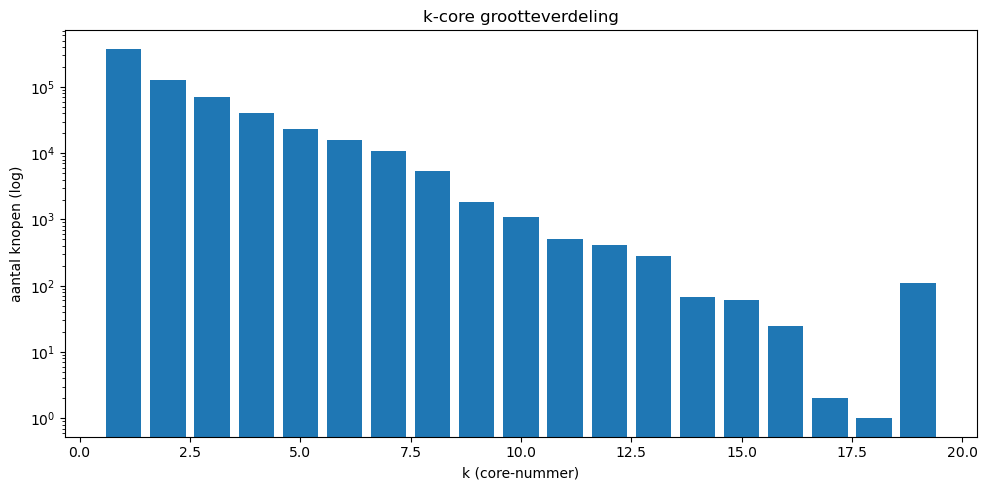

In [43]:
# verdeling plotten
ks = sorted(core_dist.keys())
counts = [core_dist[k] for k in ks]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(ks, counts)
ax.set_yscale('log')
ax.set_xlabel('k (core-nummer)')
ax.set_ylabel('aantal knopen (log)')
ax.set_title('k-core grootteverdeling')
plt.tight_layout()
plt.show()


## DV2 Verdeling van invloed

Drie maten naast elkaar: in-degree, PageRank, HITS-authority. Voor elke maat: verdeling, ongelijkheid (Gini), concentratie aan de top, en power-law-fit volgens Clauset, Shalizi en Newman (2009).

In [12]:
# in-degree
in_degree = dict(G_jur.in_degree())

# PageRank
pagerank = nx.pagerank(G_jur, alpha=0.85)

# HITS
hubs, authorities = nx.hits(G_jur, max_iter=200, tol=1e-6)

In [13]:
df_scores = pd.DataFrame({
    'ecli': list(G_jur.nodes()),
})
df_scores['in_degree'] = df_scores['ecli'].map(in_degree)
df_scores['pagerank'] = df_scores['ecli'].map(pagerank)
df_scores['authority'] = df_scores['ecli'].map(authorities)
print(df_scores.shape)
df_scores.describe()

(674589, 4)


,in_degree,pagerank,authority
count,674589.000000,6.745890e+05,6.745890e+05
mean,2.006650,1.482384e-06,1.482384e-06
std,33.048509,1.260278e-05,2.733803e-04
min,0.000000,5.987837e-07,-3.179408e-17
25%,0.000000,5.987837e-07,0.000000e+00
50%,1.000000,8.106188e-07,7.037119e-20
75%,1.000000,1.559940e-06,1.510269e-09
max,21160.000000,7.226992e-03,2.235883e-01


## ongelijkheid en concentratie

In [14]:
# Gini-coef (0 = volledig gelijk, 1 = volledig ongelijk)
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    if x.sum() == 0:
        return 0
    n = len(x)
    return (2 * np.sum(np.arange(1, n + 1) * x)) / (n * x.sum()) - (n + 1) / n

def top_k_share(x, k_frac):
    x = np.sort(np.asarray(x, dtype=float))[::-1]
    k = max(1, int(np.ceil(len(x) * k_frac)))
    return x[:k].sum() / x.sum() if x.sum() > 0 else 0.0


rows = []

for col in ['in_degree', 'pagerank', 'authority']:
    x = df_scores[col].values
    rows.append({
        'maat': col,
        'Gini': gini(x),
        'top-1%': top_k_share(x, 0.01),
        'top-5%': top_k_share(x, 0.05),
        'top-10%': top_k_share(x, 0.10)
    })

summary = pd.DataFrame(rows)

summary[['Gini', 'top-1%', 'top-5%', 'top-10%']] = summary[
    ['Gini', 'top-1%', 'top-5%', 'top-10%']
].round(3)

summary



,maat,Gini,top-1%,top-5%,top-10%
0,in_degree,0.759,0.371,0.573,0.670
1,pagerank,0.457,0.195,0.314,0.394
2,authority,0.977,0.661,0.984,0.997


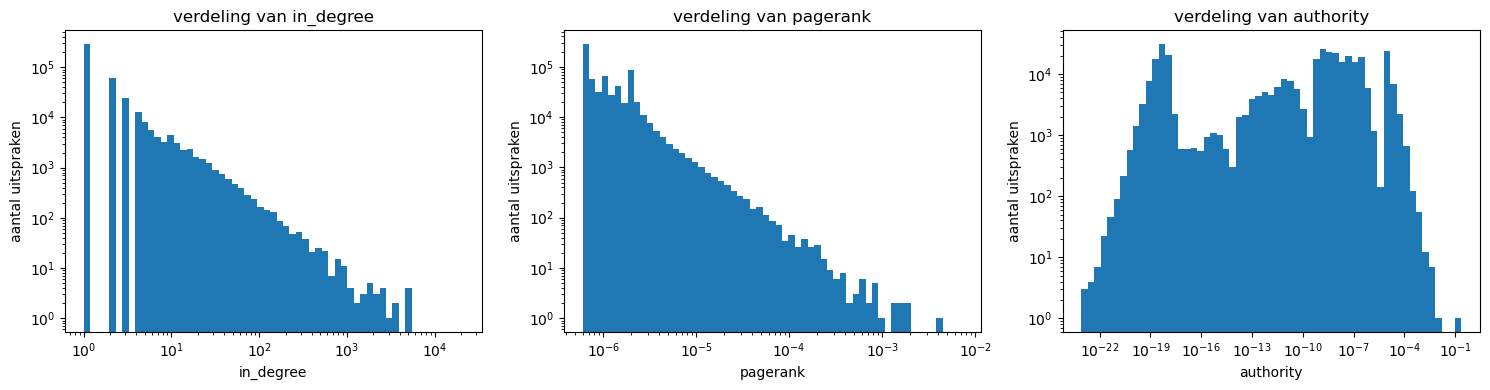

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cols = ['in_degree', 'pagerank', 'authority']

for ax, col in zip(axes, cols):
    vals = df_scores[col].values
    vals = vals[vals > 0]

    ax.hist(vals, bins=np.logspace(np.log10(vals.min()),
                                   np.log10(vals.max()), 60))

    ax.set(xscale='log',
           yscale='log',
           xlabel=col,
           ylabel='aantal uitspraken',
           title=f'verdeling van {col}')

plt.tight_layout()
plt.show()

Verdeling in-degree:
De verdeling van het in-degree heeft een gelijke afname, dus een kandidaat voor power-law .  ''survival of the fittest'', een klein aantal uitspraken wordt heel vaak geciteerd

Verdeling pagerank: Deze neemt nog gelijker af en laat ook een power-law patroon zien

Verdeling van authority: Deze wijkt heel erg af van de andere twee en heeft meerdere pieken. 

## powerlaw fits

In [16]:
import powerlaw
import warnings
warnings.filterwarnings('ignore')


In [17]:
fits = {}

for col in ['in_degree', 'pagerank', 'authority']:
    vals = df_scores[col].values
    vals = vals[vals > 0]

    fits[col] = powerlaw.Fit(vals, discrete=False, verbose=False)

In [18]:
rows = []

names = {
    'in_degree': 'In-degree',
    'pagerank': 'PageRank',
    'authority': 'HITS-authority'
}

for col, fit in fits.items():
    vals = df_scores[col].values
    vals = vals[vals > 0]

    for alt in ['lognormal', 'exponential', 'stretched_exponential']:
        R, p = fit.distribution_compare(
            'power_law',
            alt,
            normalized_ratio=True
        )

        rows.append({
            'maat': names[col],
            'alpha': fit.alpha,
            'xmin': fit.xmin,
            'KS': fit.D,
            'obs_tail': (vals >= fit.xmin).sum(),
            'vergelijking': f'power_law vs {alt}',
            'R': R,
            'p': p,
            'beste_model': 'power_law' if R > 0 else alt
        })

df_powerlaw = pd.DataFrame(rows)
df_powerlaw.round(4)

,maat,alpha,xmin,KS,obs_tail,vergelijking,R,p,beste_model
0,In-degree,2.4278,39.0000,0.0099,3136,power_law vs lognormal,-0.7030,0.4820,lognormal
1,In-degree,2.4278,39.0000,0.0099,3136,power_law vs exponential,5.8406,0.0000,power_law
2,In-degree,2.4278,39.0000,0.0099,3136,power_law vs stretched_exponential,3.2011,0.0014,power_law
3,PageRank,2.3780,0.0000,0.0048,16334,power_law vs lognormal,-0.5858,0.5580,lognormal
4,PageRank,2.3780,0.0000,0.0048,16334,power_law vs exponential,9.1380,0.0000,power_law
5,PageRank,2.3780,0.0000,0.0048,16334,power_law vs stretched_exponential,4.0513,0.0001,power_law
6,HITS-authority,2.1858,0.0002,0.0343,219,power_law vs lognormal,-1.0162,0.3096,lognormal
7,HITS-authority,2.1858,0.0002,0.0343,219,power_law vs exponential,2.2358,0.0254,power_law
8,HITS-authority,2.1858,0.0002,0.0343,219,power_law vs stretched_exponential,0.7777,0.4368,power_law


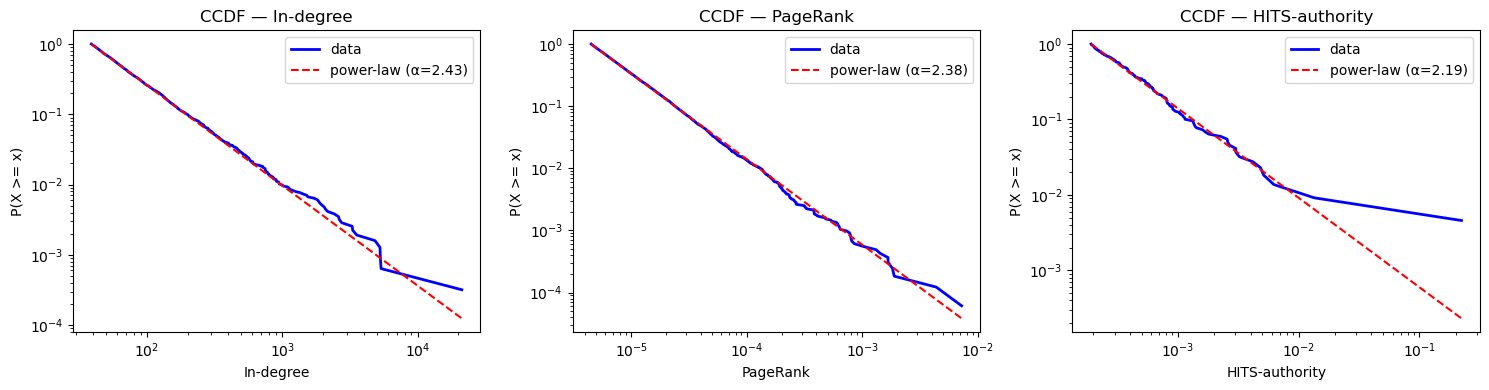

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (col, name) in zip(axes, [('in_degree', 'In-degree'),
                                   ('pagerank', 'PageRank'),
                                   ('authority', 'HITS-authority')]):
    fit = fits[col]
    fit.plot_ccdf(ax=ax, color='blue', linewidth=2, label='data')
    fit.power_law.plot_ccdf(ax=ax, color='red', linestyle='--', label=f'power-law (α={fit.alpha:.2f})')
    ax.set_xlabel(name)
    ax.set_ylabel('P(X >= x)')
    ax.set_title(f'CCDF — {name}')
    ax.legend()
plt.tight_layout()
plt.show()

- In-degree: de curve van de indegree volgt de fit redelijk goed, maar buigt op het einde rechts ietst boven de fit uit. Er is een extremere tail dan een zuivere powerlaw voorspeelt.

- Pagerank: volgt de lijn het beste van de drie, met een kleine afwijking helemaal rechts.

- HITS: rechts buigt de curve sterk boven de fit uit. Er is een groep met heel hoge authority die niet bij de powerlaw fit past, waarschijnmlijk hetzelfde HR/PHR cluster die in de SCC zit. 

## DV3 Overeenstemming tussen invloedmaten
rangcorrelatie over de volledige ranking en Jaccard-overlap aan de top

In [34]:
from scipy.stats import spearmanr, kendalltau
rows = []

pairs = [
    ('in_degree', 'pagerank'),
    ('in_degree', 'authority'),
    ('pagerank', 'authority')
]

for a, b in pairs:
    rho, _ = spearmanr(df_scores[a], df_scores[b])
    tau, _ = kendalltau(df_scores[a], df_scores[b])

    print(f'{a} vs {b:<20}  Spearman={rho:.4f}  Kendall={tau:.4f}')

in_degree vs pagerank              Spearman=0.8433  Kendall=0.7157
in_degree vs authority             Spearman=0.6461  Kendall=0.5370
pagerank vs authority             Spearman=0.3531  Kendall=0.2629


In-degree en pagerank komen best wel sterk overeen (ρ=0,84, τ=0,72), deze identificeren grotendeels dezelfde uitspraken als invloedrijk. Tussen in-degree en HITS-authority is een matige correlatie (ρ=0,65, τ=0,54). PageRank en HITS-authority hebben de allerlaagste correlatie (ρ=0,35, τ=0,26). DIt wijst erop dat HITS-authority een andere groep invloedrijke uitspraken identificeert.

top -k Jaccard overlap

In [ ]:
def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b) if a | b else 0.0

ks = [10, 100, 1000, 10_000]






## DV4  Communities en rechtsgebieden

Leiden community detection (Traag, Waltman & Van Eck, 2019) op de ongerichte projectie,

## DV5 Citaties tussen rechterlijke instanties

Per uitspraak het instantietype halen uit de ECLI, dan citatieflow tussen types in beeld brengen en Newman-assortativity berekenen.

In [42]:
# instantie-prefixen die we onderscheiden
INSTANTIE_GROEPEN = {
    'HR':   'Hoge Raad',
    'PHR':  'Parket bij de Hoge Raad',
    'RVS':  'Raad van State',
    'CRVB': 'Centrale Raad van Beroep',
    'CBB':  'College van Beroep voor het bedrijfsleven',
    # gerechtshoven (GH + 3 letters)
    'GHAMS': 'Gerechtshof', 'GHARL': 'Gerechtshof', 'GHARN': 'Gerechtshof',
    'GHDHA': 'Gerechtshof', 'GHLEE': 'Gerechtshof', 'GHSGR': 'Gerechtshof',
    'GHSHE': 'Gerechtshof',
    # rechtbanken (RB + 3 letters)
    'RBAMS': 'Rechtbank', 'RBDHA': 'Rechtbank', 'RBROT': 'Rechtbank',
    'RBMNE': 'Rechtbank', 'RBOBR': 'Rechtbank', 'RBOVE': 'Rechtbank',
    'RBNHO': 'Rechtbank', 'RBLIM': 'Rechtbank', 'RBGEL': 'Rechtbank',
    'RBNNE': 'Rechtbank', 'RBZWB': 'Rechtbank', 'RBUTR': 'Rechtbank',
    'RBARN': 'Rechtbank', 'RBSGR': 'Rechtbank', 'RBHAA': 'Rechtbank',
    'RBLEE': 'Rechtbank', 'RBSHE': 'Rechtbank', 'RBALK': 'Rechtbank',
    'RBALM': 'Rechtbank', 'RBASS': 'Rechtbank', 'RBBRE': 'Rechtbank',
    'RBDOR': 'Rechtbank', 'RBGRO': 'Rechtbank', 'RBMAA': 'Rechtbank',
    'RBMID': 'Rechtbank', 'RBROE': 'Rechtbank', 'RBZLY': 'Rechtbank',
    'RBZUT': 'Rechtbank',
}


def get_instantie(ecli):
    m = re.search(r'ECLI:NL:([A-Z]+):', ecli)
    if not m:
        return 'Onbekend'
    code = m.group(1)
    if code in INSTANTIE_GROEPEN:
        return INSTANTIE_GROEPEN[code]

    # voor onbekende 
    if code.startswith('GH'):
        return 'Gerechtshof'
    if code.startswith('RB'):
        return 'Rechtbank'
    return f'Overig ({code})'


# isnstantie per knoop
node_inst = {n: get_instantie(n) for n in G_jur.nodes()}
inst_counts = Counter(node_inst.values())


print('verdeling van instanties:')
for inst, count in inst_counts.most_common():
    print(f'  {inst:<45}{count}')

verdeling van instanties:
  Rechtbank                                    264138
  Gerechtshof                                  99112
  Hoge Raad                                    84931
  Raad van State                               67689
  Parket bij de Hoge Raad                      62383
  Centrale Raad van Beroep                     61825
  Onbekend                                     11812
  College van Beroep voor het bedrijfsleven    9900
  Overig (XX)                                  3981
  Overig (OGHACMB)                             1848
  Overig (OGEAA)                               1751
  Overig (OGEAC)                               1457
  Overig (OGEAM)                               472
  Overig (TACAKN)                              419
  Overig (OGHNAA)                              390
  Overig (OGAACMB)                             326
  Overig (TNORARL)                             277
  Overig (ORBAACM)                             241
  Overig (TGDKG)                    

# citatieflow tussen instanties

In [ ]:

flow = Counter()
for u, v in G_jur.edges():
    flow[(node_inst[u], node_inst[v])] += 1


instanties = sorted({i for i in node_inst.values()})

# matrix met rij=citerende, kolom=geciteerde
mat = np.zeros((len(instanties), len(instanties)))
for i, src in enumerate(instanties):
    for j, tgt in enumerate(instanties):
        mat[i, j] = flow.get((src, tgt), 0)

        
df_flow_abs = pd.DataFrame(mat, index=instanties, columns=instanties).astype(int)
print('absolute citatieflow (rij citeert kolom):')
display(df_flow_abs)

absolute citatieflow (rij citeert kolom):


,Centrale Raad van Beroep,College van Beroep voor het bedrijfsleven,Gerechtshof,Hoge Raad,Onbekend,Overig (AGAMS),Overig (AGROT),Overig (AGSGR),Overig (CG),Overig (CVBSTUF),...,Overig (TNORAMS),Overig (TNORARL),Overig (TNORDHA),Overig (TNORSHE),Overig (TRMTSGR),Overig (TSCTS),Overig (XX),Parket bij de Hoge Raad,Raad van State,Rechtbank
Centrale Raad van Beroep,63149,124,210,3243,7273,0,1,1,0,7,...,0,0,0,0,0,0,704,32,910,32272
College van Beroep voor het bedrijfsleven,191,15299,160,887,3066,0,0,0,0,0,...,0,0,0,0,0,1,780,16,840,1607
Gerechtshof,616,180,26803,113237,28335,0,0,0,0,0,...,110,288,113,124,0,0,5457,4986,1230,37612
Hoge Raad,966,49,24658,26257,10086,0,0,0,0,1,...,0,7,0,0,0,0,2083,61025,224,3154
Onbekend,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Overig (TSCTS),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Overig (XX),0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Parket bij de Hoge Raad,710,232,13342,202605,20055,0,0,2,0,2,...,7,14,3,1,0,0,6377,12736,1248,7877
Raad van State,392,171,224,1180,12871,0,0,0,0,0,...,0,1,0,0,0,0,2345,25,73074,33346


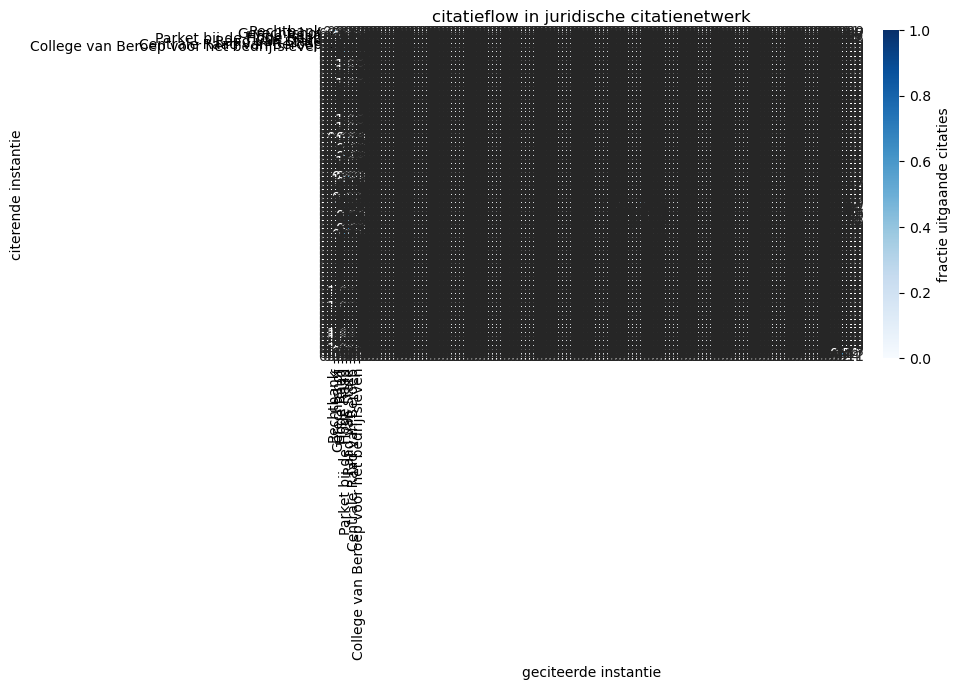

In [ ]:
# plotten in heatmap
# zonder obekend en overig voor de heatmap
clean_inst = ['Rechtbank', 'Gerechtshof', 'Hoge Raad', 'Parket bij de Hoge Raad',
              'Raad van State', 'Centrale Raad van Beroep',
              'College van Beroep voor het bedrijfsleven']
clean_inst = [i for i in clean_inst if i in instanties]


mat_row_norm = mat / mat.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(mat_row_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=clean_inst, yticklabels=clean_inst, ax=ax,
            cbar_kws={'label': 'fractie uitgaande citaties'})
ax.set_xlabel('geciteerde instantie')
ax.set_ylabel('citerende instantie')
ax.set_title('citatieflow in juridische citatienetwerk')
plt.tight_layout()
plt.show()


# newman assortativity op instantitype


In [53]:
nx.set_node_attributes(G_jur, node_inst, name='instantie')
r = nx.attribute_assortativity_coefficient(G_jur, 'instantie')